<a href="https://colab.research.google.com/github/h3692/amd-propensity-to-buy/blob/main/baynesian_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import re
import joblib
import scipy.sparse as sp
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, CategoricalNB
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

POSITIVE_CSV = 'pipeline_results.csv'
NEGATIVE_CSV = 'negative_dataset (1).csv'
ARTIFACT_PATH = 'bayesian_engine_artifacts.pkl'

BASE_PRIOR = 0.03

COL_ID         = 'Canonical ID [canonical_id]'
COL_NAME       = 'Company Name [canonical_name]'
COL_CLOUD      = 'Cloud Platforms [cloud_platforms]'
COL_VIRT       = 'Virtualization Tools [virtualization_tools]'
COL_INFRA      = 'Infrastructure Software [infrastructure_software]'
COL_INTENT     = 'Intent Topics [intent_topics]'
COL_KEYWORDS   = 'Keywords [keywords]'
COL_RESEARCH   = 'Active Research Areas [active_research_categories]'
COL_SCOOP_HIRE = 'Hiring Scoops (ZoomInfo) [hiring_scoops]'
COL_SCOOP_TECH = 'Technology Scoops (ZoomInfo) [technology_scoops]'
COL_SCOOP_PART = 'Partnership Scoops (ZoomInfo) [partnership_scoops]'
COL_PROC_AMD   = 'Processor Flag Amd Pro [processor_flag_amd_pro]'
COL_PROC_INTEL = 'Processor Flag Intel Vpro [processor_flag_intel_vpro]'
COL_GOV        = 'Government / National Lab [gov_lab_flag]'
COL_OWNERSHIP  = 'Ownership Type [public_private]'

In [10]:
def parse_semicolon_list(series):
    return series.fillna('').apply(
        lambda x: [item.strip() for item in str(x).split(';') if item.strip()]
    )

def parse_intent_topics(series):
    def _extract(text):
        if pd.isna(text) or not str(text).strip():
            return []
        return [m.strip() for m in re.findall(r'topic:\s*([^;]+)', str(text))]
    return series.apply(_extract)

def create_binary_flags(df):
    out = pd.DataFrame(index=df.index)

    out['Gov_Lab_Numeric'] = (
        df[COL_GOV].astype(str).str.strip().str.upper()
        .map({'YES': 1, 'NO': 0})
        .fillna(0).astype(int)
    )

    ownership = df[COL_OWNERSHIP].astype(str).str.strip().str.upper()
    ownership = ownership.replace({'NAN': 'UNKNOWN', '': 'UNKNOWN'})
    out['Ownership_Type_Public']  = ownership.isin(['PUBLIC']).astype(int)
    out['Ownership_Type_Private'] = ownership.isin(['PRIVATE']).astype(int)
    out['Ownership_Type_Unknown'] = (
        ~ownership.isin(['PUBLIC', 'PRIVATE'])
    ).astype(int)

    for col, name in [
        (COL_PROC_AMD,   'Processor_Flag_Amd_Pro'),
        (COL_PROC_INTEL, 'Processor_Flag_Intel_Vpro'),
    ]:
        out[name] = (
            df[col].astype(str).str.strip().str.upper()
            .map({'YES': 1, 'NO': 0})
            .fillna(0).astype(int)
        )

    for col, name in [
        (COL_SCOOP_HIRE, 'Has_Hiring_Scoop'),
        (COL_SCOOP_TECH, 'Has_Tech_Scoop'),
        (COL_SCOOP_PART, 'Has_Partnership_Scoop'),
    ]:
        out[name] = df[col].notna().astype(int)

    return out

def safe_mlb_transform(mlb, label_series):
    known = set(mlb.classes_)
    filtered = label_series.apply(lambda lst: [l for l in lst if l in known])
    return mlb.transform(filtered)

In [11]:
df_pos = pd.read_csv(POSITIVE_CSV, encoding='utf-8-sig')
df_neg = pd.read_csv(NEGATIVE_CSV, encoding='utf-8-sig')

df_pos['label'] = 1
df_neg['label'] = 0

df_train = pd.concat([df_pos, df_neg], ignore_index=True)

print(f"Positive (winners) : {len(df_pos):>4d} rows")
print(f"Negative (losers)  : {len(df_neg):>4d} rows")
print(f"Combined training  : {len(df_train):>4d} rows")
print(f"Base Prior         : {BASE_PRIOR:.2%}")

Positive (winners) :  126 rows
Negative (losers)  :  150 rows
Combined training  :  276 rows
Base Prior         : 3.00%


In [12]:
flag_features = create_binary_flags(df_train)
X_categorical = flag_features.values.astype(int)

print(f"CategoricalNB feature matrix : {X_categorical.shape}")
print(f"\n{'Feature':<32s}  {'Winners':>8s}  {'Losers':>8s}")
print("-" * 54)
y_temp = df_train['label'].values
for i, col in enumerate(flag_features.columns):
    w = X_categorical[y_temp == 1, i].mean()
    l = X_categorical[y_temp == 0, i].mean()
    print(f"  {col:<30s}  {w:>7.1%}  {l:>7.1%}")

CategoricalNB feature matrix : (276, 9)

Feature                            Winners    Losers
------------------------------------------------------
  Gov_Lab_Numeric                    6.3%     0.0%
  Ownership_Type_Public             77.8%    70.7%
  Ownership_Type_Private            21.4%    29.3%
  Ownership_Type_Unknown             0.8%     0.0%
  Processor_Flag_Amd_Pro             0.0%     0.0%
  Processor_Flag_Intel_Vpro          0.8%     1.3%
  Has_Hiring_Scoop                  20.6%    37.3%
  Has_Tech_Scoop                    48.4%    24.7%
  Has_Partnership_Scoop             33.3%    29.3%


In [13]:
cloud_labels  = parse_semicolon_list(df_train[COL_CLOUD])
virt_labels   = parse_semicolon_list(df_train[COL_VIRT])
infra_labels  = parse_semicolon_list(df_train[COL_INFRA])
intent_labels = parse_intent_topics(df_train[COL_INTENT])

mlb_cloud  = MultiLabelBinarizer()
mlb_virt   = MultiLabelBinarizer()
mlb_infra  = MultiLabelBinarizer()
mlb_intent = MultiLabelBinarizer()

X_cloud  = mlb_cloud.fit_transform(cloud_labels)
X_virt   = mlb_virt.fit_transform(virt_labels)
X_infra  = mlb_infra.fit_transform(infra_labels)
X_intent = mlb_intent.fit_transform(intent_labels)

print("Exploded-list feature dimensions:")
print(f"  Cloud Platforms          : {X_cloud.shape[1]:>4d} binary columns")
print(f"  Virtualization Tools     : {X_virt.shape[1]:>4d} binary columns")
print(f"  Infrastructure Software  : {X_infra.shape[1]:>4d} binary columns")
print(f"  Intent Topics            : {X_intent.shape[1]:>4d} binary columns")
print(f"  TOTAL (exploded lists)   : {X_cloud.shape[1]+X_virt.shape[1]+X_infra.shape[1]+X_intent.shape[1]:>4d}")

Exploded-list feature dimensions:
  Cloud Platforms          :  108 binary columns
  Virtualization Tools     :  272 binary columns
  Infrastructure Software  :  790 binary columns
  Intent Topics            :   59 binary columns
  TOTAL (exploded lists)   : 1229


In [14]:
keywords_text = (df_train[COL_KEYWORDS].fillna('').astype(str).str.replace(';', ' ', regex=False))
research_text = (df_train[COL_RESEARCH].fillna('').astype(str).str.replace(';', ' ', regex=False))
combined_nlp_text = keywords_text + ' ' + research_text

pos_mask = df_train['label'] == 1

cv = CountVectorizer(
    binary=True,
    max_features=500,
    stop_words='english',
    min_df=2,
)
cv.fit(combined_nlp_text[pos_mask])

X_text = cv.transform(combined_nlp_text)

print(f"CountVectorizer vocabulary : {len(cv.vocabulary_)} words")
print(f"NLP text matrix            : {X_text.shape}")

vocab_freq = np.asarray(X_text[pos_mask.values].sum(axis=0)).flatten()
top_idx = vocab_freq.argsort()[::-1][:20]
feat_names = cv.get_feature_names_out()
print(f"\nTop 20 keywords among winners (out of {pos_mask.sum()}):")
for rank, i in enumerate(top_idx, 1):
    print(f"  {rank:>2d}. {feat_names[i]:<30s}  {int(vocab_freq[i]):>3d} companies")

CountVectorizer vocabulary : 500 words
NLP text matrix            : (276, 500)

Top 20 keywords among winners (out of 126):
   1. laptop                          113 companies
   2. samsung                         111 companies
   3. galaxy                          111 companies
   4. services                        110 companies
   5. hardware                        110 companies
   6. ipad                            108 companies
   7. apple                           108 companies
   8. technology                      105 companies
   9. management                      105 companies
  10. headphones                      103 companies
  11. headset                         103 companies
  12. conferencing                    103 companies
  13. hp                              103 companies
  14. marketing                       103 companies
  15. video                           102 companies
  16. tab                              98 companies
  17. infrastructure                   97 co

In [15]:
X_multinomial = sp.hstack([
    sp.csr_matrix(X_cloud),
    sp.csr_matrix(X_virt),
    sp.csr_matrix(X_infra),
    sp.csr_matrix(X_intent),
    X_text,
], format='csr')

y = df_train['label'].values

print(f"MultinomialNB features : {X_multinomial.shape}  (sparse)")
print(f"CategoricalNB features : {X_categorical.shape}  (dense int)")
print(f"Labels                 : {y.shape} (pos={y.sum()}, neg={(1 - y).sum()})")

MultinomialNB features : (276, 1729)  (sparse)
CategoricalNB features : (276, 9)  (dense int)
Labels                 : (276,)  (pos=126, neg=150)


In [16]:
text_bayes = MultinomialNB(
    alpha=1.0,
    class_prior=[1 - BASE_PRIOR, BASE_PRIOR],
)
text_bayes.fit(X_multinomial, y)

text_probs = text_bayes.predict_proba(X_multinomial)[:, 1]

print("Text Bayes (MultinomialNB) -- training-set probabilities:")
print(f"  Winners  mean={text_probs[y==1].mean():.4f}  median={np.median(text_probs[y==1]):.4f}  min={text_probs[y==1].min():.4f}  max={text_probs[y==1].max():.4f}")
print(f"  Losers   mean={text_probs[y==0].mean():.4f}  median={np.median(text_probs[y==0]):.4f}  min={text_probs[y==0].min():.4f}  max={text_probs[y==0].max():.4f}")

Text Bayes (MultinomialNB) -- training-set probabilities:
  Winners  mean=0.8116  median=1.0000  min=0.0000  max=1.0000
  Losers   mean=0.1003  median=0.0000  min=0.0000  max=1.0000


In [17]:
flag_bayes = CategoricalNB(
    alpha=1.0,
    class_prior=[1 - BASE_PRIOR, BASE_PRIOR],
    min_categories=2,
)
flag_bayes.fit(X_categorical, y)

flag_probs = flag_bayes.predict_proba(X_categorical)[:, 1]

print("Flag Bayes (CategoricalNB) -- training-set probabilities:")
print(f"  Winners  mean={flag_probs[y==1].mean():.4f}  median={np.median(flag_probs[y==1]):.4f}  min={flag_probs[y==1].min():.4f}  max={flag_probs[y==1].max():.4f}")
print(f"  Losers   mean={flag_probs[y==0].mean():.4f}  median={np.median(flag_probs[y==0]):.4f}  min={flag_probs[y==0].min():.4f}  max={flag_probs[y==0].max():.4f}")

Flag Bayes (CategoricalNB) -- training-set probabilities:
  Winners  mean=0.0530  median=0.0348  min=0.0126  max=0.3538
  Losers   mean=0.0281  median=0.0279  min=0.0059  max=0.0887


In [18]:
bayes_reality_check = (text_probs + flag_probs) / 2

pos_scores = bayes_reality_check[y == 1]
neg_scores = bayes_reality_check[y == 0]

print("ENSEMBLE -- Bayes Reality Check Probability")
print(f"\n  Winners (n={len(pos_scores)}):")
print(f"    Mean   : {pos_scores.mean():.4f}")
print(f"    Median : {np.median(pos_scores):.4f}")
print(f"    Min    : {pos_scores.min():.4f}")
print(f"    Max    : {pos_scores.max():.4f}")
print(f"\n  Losers (n={len(neg_scores)}):")
print(f"    Mean   : {neg_scores.mean():.4f}")
print(f"    Median : {np.median(neg_scores):.4f}")
print(f"    Min    : {neg_scores.min():.4f}")
print(f"    Max    : {neg_scores.max():.4f}")

auc = roc_auc_score(y, bayes_reality_check)
print(f"\n  ROC AUC (training set) : {auc:.4f}")

threshold = BASE_PRIOR
preds = (bayes_reality_check >= threshold).astype(int)
print(f"\n  Classification @ threshold = {threshold:.2%}:")
print(classification_report(y, preds, target_names=['Loser', 'Winner']))

cv_auc = cross_val_score(
    MultinomialNB(alpha=1.0, class_prior=[1 - BASE_PRIOR, BASE_PRIOR]),
    X_multinomial, y, cv=5, scoring='roc_auc',
)
print(f"  5-fold CV ROC AUC (Text Bayes only) : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")

ENSEMBLE -- Bayes Reality Check Probability

  Winners (n=126):
    Mean   : 0.4323
    Median : 0.5167
    Min    : 0.0063
    Max    : 0.6235

  Losers (n=150):
    Mean   : 0.0642
    Median : 0.0140
    Min    : 0.0029
    Max    : 0.5374

  ROC AUC (training set) : 0.9185

  Classification @ threshold = 3.00%:
              precision    recall  f1-score   support

       Loser       0.88      0.80      0.84       150
      Winner       0.78      0.87      0.82       126

    accuracy                           0.83       276
   macro avg       0.83      0.83      0.83       276
weighted avg       0.83      0.83      0.83       276

  5-fold CV ROC AUC (Text Bayes only) : 0.9175 +/- 0.0484


In [19]:
artifacts = {
    'mlb_cloud':        mlb_cloud,
    'mlb_virt':         mlb_virt,
    'mlb_infra':        mlb_infra,
    'mlb_intent':       mlb_intent,
    'count_vectorizer': cv,
    'text_bayes':       text_bayes,
    'flag_bayes':       flag_bayes,
    'base_prior':       BASE_PRIOR,
    'flag_columns':     list(flag_features.columns),
}

joblib.dump(artifacts, ARTIFACT_PATH)
print(f"Artifacts saved -> {ARTIFACT_PATH}")

Artifacts saved -> bayesian_engine_artifacts.pkl
  Keys: ['mlb_cloud', 'mlb_virt', 'mlb_infra', 'mlb_intent', 'count_vectorizer', 'text_bayes', 'flag_bayes', 'base_prior', 'flag_columns']


In [20]:
def score_lookalikes(prospect_csv, artifacts_path=ARTIFACT_PATH, output_csv='scored_lookalikes.csv', rf_prob_col=None):
    art = joblib.load(artifacts_path)
    _mlb_cloud  = art['mlb_cloud']
    _mlb_virt   = art['mlb_virt']
    _mlb_infra  = art['mlb_infra']
    _mlb_intent = art['mlb_intent']
    _cv         = art['count_vectorizer']
    _text_bayes = art['text_bayes']
    _flag_bayes = art['flag_bayes']
    _base_prior = art['base_prior']

    df = pd.read_csv(prospect_csv, encoding='utf-8-sig')

    flags = create_binary_flags(df)
    X_cat = flags.values.astype(int)

    X_cl = safe_mlb_transform(_mlb_cloud,  parse_semicolon_list(df[COL_CLOUD]))
    X_vi = safe_mlb_transform(_mlb_virt,   parse_semicolon_list(df[COL_VIRT]))
    X_in = safe_mlb_transform(_mlb_infra,  parse_semicolon_list(df[COL_INFRA]))
    X_it = safe_mlb_transform(_mlb_intent, parse_intent_topics(df[COL_INTENT]))

    kw = df[COL_KEYWORDS].fillna('').astype(str).str.replace(';', ' ', regex=False)
    ra = df[COL_RESEARCH].fillna('').astype(str).str.replace(';', ' ', regex=False)
    X_nlp = _cv.transform(kw + ' ' + ra)

    X_multi = sp.hstack([
        sp.csr_matrix(X_cl),
        sp.csr_matrix(X_vi),
        sp.csr_matrix(X_in),
        sp.csr_matrix(X_it),
        X_nlp,
    ], format='csr')

    text_prob = _text_bayes.predict_proba(X_multi)[:, 1]
    flag_prob = _flag_bayes.predict_proba(X_cat)[:, 1]
    bayes_prob = (text_prob + flag_prob) / 2

    result = df[[COL_ID, COL_NAME]].copy()
    result['Text_Prob']                = np.round(text_prob, 6)
    result['Flag_Prob']                = np.round(flag_prob, 6)
    result['Bayes_Reality_Check_Prob'] = np.round(bayes_prob, 6)

    if rf_prob_col and rf_prob_col in df.columns:
        rf = df[rf_prob_col].values.astype(float)
        scaler = bayes_prob / _base_prior
        calibrated = np.clip(rf * scaler, 0.0, 1.0)
        result['RF_Probability']             = np.round(rf, 6)
        result['Bayesian_Scaler']            = np.round(scaler, 4)
        result['Calibrated_Win_Probability'] = np.round(calibrated, 6)
    else:
        result['Calibrated_Win_Probability'] = np.round(bayes_prob, 6)

    result = result.sort_values('Calibrated_Win_Probability', ascending=False)
    result.to_csv(output_csv, index=False)
    return result

In [21]:
demo = score_lookalikes(
    prospect_csv=POSITIVE_CSV,
    artifacts_path=ARTIFACT_PATH,
    output_csv='scored_focus_companies.csv',
    rf_prob_col=None,
)

print("\nTop 15 scored Focus Companies:")
print(demo.head(15).to_string(index=False))

print("\nBottom 5 scored Focus Companies:")
print(demo.tail(5).to_string(index=False))

Loaded 126 prospects from pipeline_results.csv
Scored output saved -> scored_focus_companies.csv  (126 rows)

Top 15 scored Focus Companies:
Canonical ID [canonical_id]          Company Name [canonical_name]  Text_Prob  Flag_Prob  Bayes_Reality_Check_Prob  Calibrated_Win_Probability
                zi_34785628              U.S. Department of Energy   1.000000   0.246973                  0.623486                    0.623486
                zi_55969411 Lawrence Livermore National Laboratory   1.000000   0.132013                  0.566006                    0.566006
                zi_38487278          Oak Ridge National Laboratory   1.000000   0.132013                  0.566006                    0.566006
                 zi_5374735         Los Alamos National laboratory   1.000000   0.132013                  0.566006                    0.566006
                zi_78808712              Idaho National Laboratory   1.000000   0.132013                  0.566006                    0.566006
 

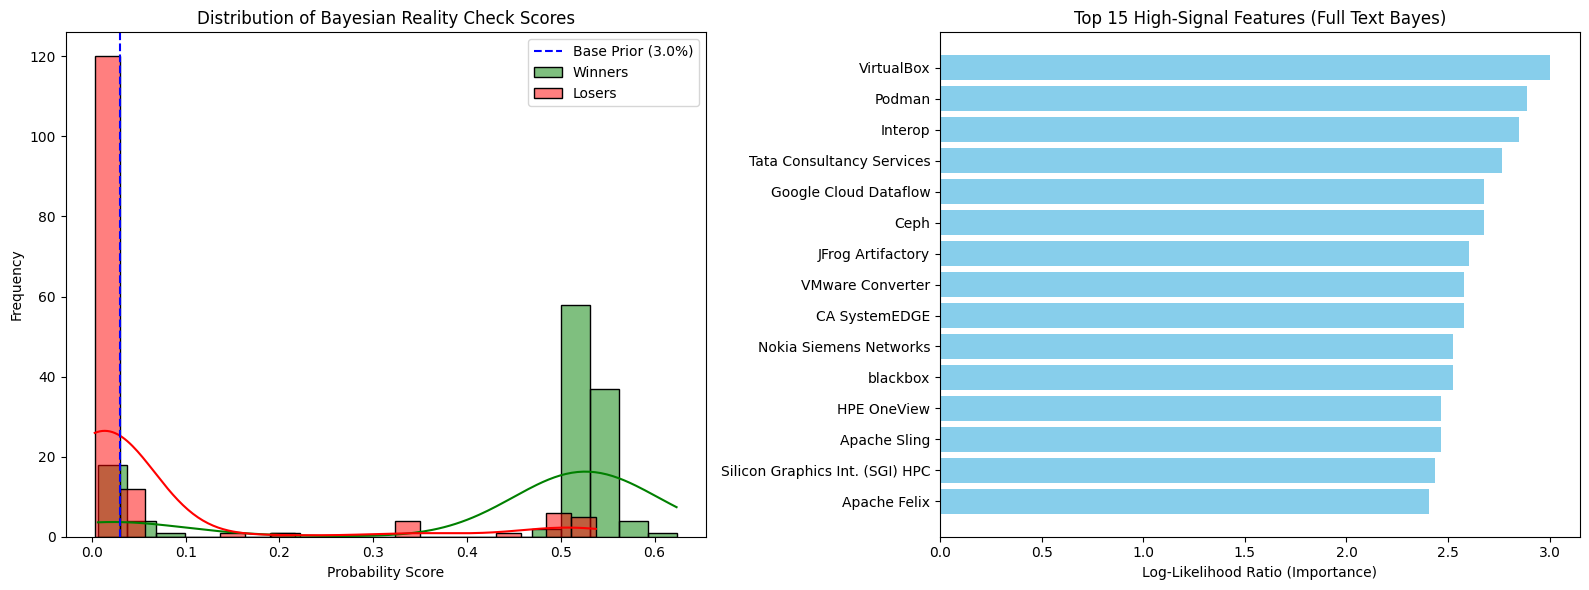

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_feat_names = np.concatenate([
    mlb_cloud.classes_,
    mlb_virt.classes_,
    mlb_infra.classes_,
    mlb_intent.classes_,
    cv.get_feature_names_out()
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(pos_scores, bins=20, label='Winners', color='green', alpha=0.5, ax=ax1, kde=True)
sns.histplot(neg_scores, bins=20, label='Losers', color='red', alpha=0.5, ax=ax1, kde=True)
ax1.axvline(BASE_PRIOR, color='blue', linestyle='--', label=f'Base Prior ({BASE_PRIOR:.1%})')
ax1.set_title('Distribution of Bayesian Reality Check Scores')
ax1.set_xlabel('Probability Score')
ax1.set_ylabel('Frequency')
ax1.legend()

log_probs = text_bayes.feature_log_prob_[1] - text_bayes.feature_log_prob_[0]
top_indices = log_probs.argsort()[-15:]
top_labels = all_feat_names[top_indices]
top_scores = log_probs[top_indices]

ax2.barh(top_labels, top_scores, color='skyblue')
ax2.set_title('Top 15 High-Signal Features (Full Text Bayes)')
ax2.set_xlabel('Log-Likelihood Ratio (Importance)')

plt.tight_layout()
plt.show()